# AICE 모의고사 3회 - 대출 상환 예측

## 문제 시나리오

대출 신청자의 개인 정보 및 금융 데이터를 분석 및 전처리한 후 머신러닝과 딥러닝으로 대출 상환 가능성 점수를 예측하고 결과를 분석하세요. (상환 가능성 점수는 0-100 사이의 숫자 값)

## 3-1 | 라이브러리 임포트 및 데이터 로딩

### 【 문제 】

- scikit-learn을 sk로, pandas를 pd로 임포트하세요.
- loan_applicants.json을 읽어 df_applicants에 저장하세요.
- financial_history.csv를 읽어 df_history에 저장하세요.

In [89]:
import sklearn as sk
import pandas as pd

In [90]:
df_applicant = pd.read_json('C:/juehyeon/aice_test/기출문제/3.대출상환예측/loan_applicants_2.json')

In [91]:
df_history = pd.read_csv('C:/juehyeon/aice_test/기출문제/3.대출상환예측/financial_history_3.csv')

## 3-2 | 데이터 병합 및 초기 탐색

### 【 문제 】

- ApplicantID 기준으로 inner join하여 df 생성하세요.
- df.info( )와 df.head( )로 데이터 기본 구조를 확인하세요.

In [92]:
df = pd.merge(df_applicant, df_history, on = 'ApplicantID', how = 'inner')

In [93]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117 entries, 0 to 116
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ApplicantID           117 non-null    int64  
 1   Age                   117 non-null    int64  
 2   Income_USD            117 non-null    int64  
 3   CreditScore           112 non-null    float64
 4   LoanAmount_USD        117 non-null    int64  
 5   LoanTerm_months       117 non-null    int64  
 6   EmploymentType        117 non-null    object 
 7   EducationLevel        117 non-null    object 
 8   NumCreditCards        117 non-null    int64  
 9   DebtToIncomeRatio     117 non-null    float64
 10  PreviousLoanDefaults  117 non-null    int64  
 11  AnnualIncome          111 non-null    float64
 12  RepaymentScore        117 non-null    int64  
dtypes: float64(3), int64(8), object(2)
memory usage: 12.0+ KB


In [94]:
df.head()

,ApplicantID,Age,Income_USD,CreditScore,LoanAmount_USD,LoanTerm_months,EmploymentType,EducationLevel,NumCreditCards,DebtToIncomeRatio,PreviousLoanDefaults,AnnualIncome,RepaymentScore
0,1,36,161932,406.0,81820,24,Salaried,Masters,1,0.16,3,160462.0,71
1,2,45,117498,672.0,49131,36,Salaried,Bachelors,1,0.19,2,115058.0,78
2,3,51,89735,685.0,10311,48,Salaried,HighSchool,7,0.39,3,90203.0,67
3,4,43,105305,NaN,98016,12,Self-Employed,Masters,2,0.50,1,107246.0,67
4,5,49,142537,489.0,89654,36,Self-Employed,PhD,4,0.19,2,145083.0,62


## 3-3 | 범주형 변수 로트 시각화 및 데이터 경제

### 【 문제 】

- EmploymentType 분포를 countplot으로 시각화하세요.
- EmploymentType 값 중 'Unemployed'를 가진 행을 삭제하세요.
- 삭제된 행 개수를 답안03에 저장하세요.

In [95]:
import seaborn as sns

<Axes: xlabel='EmploymentType', ylabel='count'>

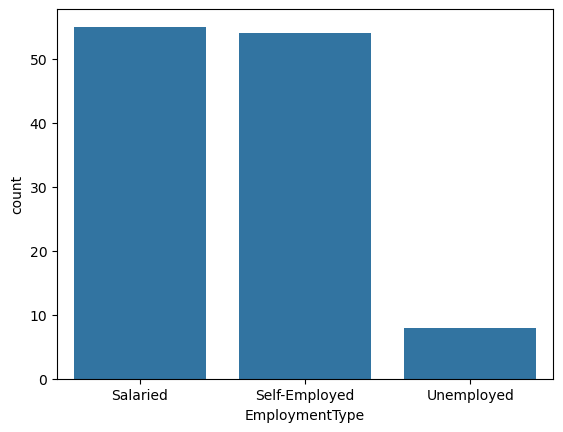

In [96]:
sns.countplot(data = df, x= 'EmploymentType')

In [97]:
initial_rows= df['EmploymentType'].shape[0]
unemployed_rows = df[df['EmploymentType'] != 'Unemployed'].copy().shape[0]
답안03= initial_rows - unemployed_rows

In [98]:
df = df[df['EmploymentType'] != 'Unemployed'].copy()

<Axes: xlabel='EmploymentType', ylabel='count'>

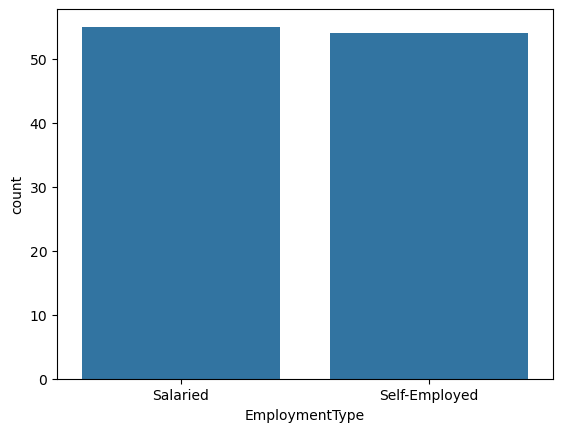

In [99]:
sns.countplot(data = df, x = 'EmploymentType')

## 3-4 | 수치형 변수 관계 시각화 및 이상치 탐색

### 【 문제 】

- Income_USD와 RepaymentScore의 jointplot을 그리세요.
- Income_USD ≥ 300000을 이상치로 간주하고 개수를 답안04에 저장하세요.


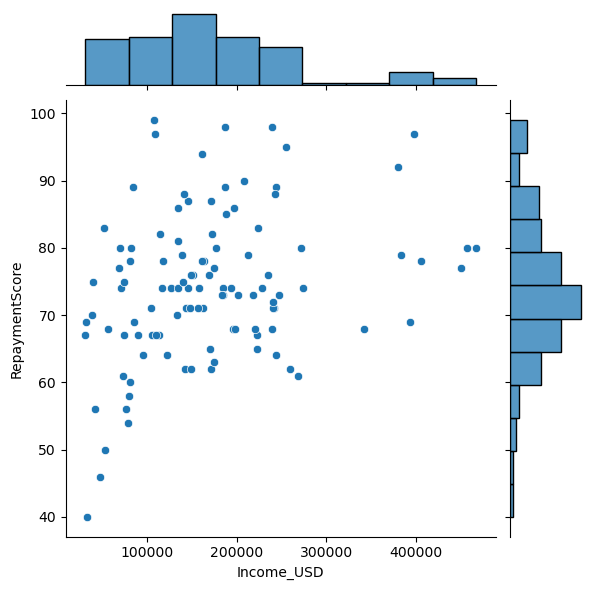

In [100]:
sns.jointplot(data = df, x = 'Income_USD', y = 'RepaymentScore')

In [101]:
답안04 = df[df['Income_USD'] >= 300000].shape[0]
print(답안04)

9


## 3-5 | 이상치 및 불필요 컬럼 처리

### 【 문제 】

- Income_USD ≥ 300000 이상치를 제거하세요.
- ApplicantID 컬럼을 삭제하세요.
- 결과를 df_temp에 저장하세요.

In [102]:
df_temp = df[df['Income_USD'] < 300000].copy()

In [103]:
df_temp = df_temp.drop(columns = 'ApplicantID', axis = 1)

In [104]:
df_temp

,Age,Income_USD,CreditScore,LoanAmount_USD,LoanTerm_months,EmploymentType,EducationLevel,NumCreditCards,DebtToIncomeRatio,PreviousLoanDefaults,AnnualIncome,RepaymentScore
0,36,161932,406.0,81820,24,Salaried,Masters,1,0.16,3,160462.0,71
1,45,117498,672.0,49131,36,Salaried,Bachelors,1,0.19,2,115058.0,78
2,51,89735,685.0,10311,48,Salaried,HighSchool,7,0.39,3,90203.0,67
3,43,105305,NaN,98016,12,Self-Employed,Masters,2,0.50,1,107246.0,67
4,49,142537,489.0,89654,36,Self-Employed,PhD,4,0.19,2,145083.0,62
...,...,...,...,...,...,...,...,...,...,...,...,...
112,27,109252,812.0,21907,24,Salaried,Bachelors,5,0.58,3,NaN,97
113,48,121865,372.0,28321,12,Salaried,Masters,4,0.53,3,126381.0,64
114,51,161550,406.0,24262,60,Self-Employed,HighSchool,1,0.39,3,162733.0,78
115,29,240176,552.0,92731,24,Salaried,PhD,4,0.47,3,242490.0,72


In [105]:
df_temp.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100 entries, 0 to 116
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   100 non-null    int64  
 1   Income_USD            100 non-null    int64  
 2   CreditScore           96 non-null     float64
 3   LoanAmount_USD        100 non-null    int64  
 4   LoanTerm_months       100 non-null    int64  
 5   EmploymentType        100 non-null    object 
 6   EducationLevel        100 non-null    object 
 7   NumCreditCards        100 non-null    int64  
 8   DebtToIncomeRatio     100 non-null    float64
 9   PreviousLoanDefaults  100 non-null    int64  
 10  AnnualIncome          94 non-null     float64
 11  RepaymentScore        100 non-null    int64  
dtypes: float64(3), int64(7), object(2)
memory usage: 10.2+ KB


## 3-6 | 결측치 처리 및 데이터 타입 변환

### 【 문제 】

- 결측치를 확인하고, AnnualIncome과 CreditScore 컬럼에 있는 결측치를 각 컬럼의 평균값으로 대체하세요.
- 결과를 df_na에 저장하고, 결측치가 대체된 총 개수를 답안06에 저장하세요.


In [106]:
df_temp.isna().sum()

Age                     0
Income_USD              0
CreditScore             4
LoanAmount_USD          0
LoanTerm_months         0
EmploymentType          0
EducationLevel          0
NumCreditCards          0
DebtToIncomeRatio       0
PreviousLoanDefaults    0
AnnualIncome            6
RepaymentScore          0
dtype: int64

In [107]:
답안06 = (df_temp['AnnualIncome'].isna().sum()) + (df_temp['CreditScore'].isna().sum())

In [108]:
mean_income = df_temp['AnnualIncome'].mean()
mean_credit_score = df_temp['CreditScore'].mean()

In [109]:
df_temp['AnnualIncome'] = df_temp['AnnualIncome'].fillna(mean_income)
df_temp['CreditScore'] = df_temp['CreditScore'].fillna(mean_credit_score)
df_na = df_temp.copy()

## 3-7 | 불필요 컬럼 처리 및 원-핫 인코딩

### 【 문제 】

- EmploymentType, EducationLevel을 원-핫 인코딩하세요.
- 결과를 df_encoded에 저장하세요.

In [110]:
df_na['EmploymentType']

0           Salaried
1           Salaried
2           Salaried
3      Self-Employed
4      Self-Employed
           ...      
112         Salaried
113         Salaried
114    Self-Employed
115         Salaried
116         Salaried
Name: EmploymentType, Length: 100, dtype: object

In [111]:
df_encoded = df_na.copy()

In [112]:
df_encoded = pd.get_dummies(df_encoded, columns = ['EmploymentType', 'EducationLevel'])

In [113]:
df_encoded

,Age,Income_USD,CreditScore,LoanAmount_USD,LoanTerm_months,NumCreditCards,DebtToIncomeRatio,PreviousLoanDefaults,AnnualIncome,RepaymentScore,EmploymentType_Salaried,EmploymentType_Self-Employed,EducationLevel_Bachelors,EducationLevel_HighSchool,EducationLevel_Masters,EducationLevel_PhD
0,36,161932,406.0000,81820,24,1,0.16,3,160462.000000,71,True,False,False,False,True,False
1,45,117498,672.0000,49131,36,1,0.19,2,115058.000000,78,True,False,True,False,False,False
2,51,89735,685.0000,10311,48,7,0.39,3,90203.000000,67,True,False,False,True,False,False
3,43,105305,560.0625,98016,12,2,0.50,1,107246.000000,67,False,True,False,False,True,False
4,49,142537,489.0000,89654,36,4,0.19,2,145083.000000,62,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112,27,109252,812.0000,21907,24,5,0.58,3,147876.702128,97,True,False,True,False,False,False
113,48,121865,372.0000,28321,12,4,0.53,3,126381.000000,64,True,False,False,False,True,False
114,51,161550,406.0000,24262,60,1,0.39,3,162733.000000,78,False,True,False,True,False,False
115,29,240176,552.0000,92731,24,4,0.47,3,242490.000000,72,True,False,False,False,False,True


## 3-8 | 데이터 분리 및 스케일링

### 【 문제 】

- RepaymentScore를 y로, 나머지를 X로 설정하세요.
- train_test_split으로 80:20 분할하고 random_state=42로 설정하세요.
- StandardScaler로 스케일링하세요.

In [114]:
X = df_encoded.drop(columns = 'RepaymentScore', axis = 1)
y = df_encoded['RepaymentScore']

In [115]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [116]:
ss = StandardScaler()

In [117]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [118]:
X_train_scaled = ss.fit_transform(X_train)
X_valid_scaled = ss.transform(X_valid)

## 3-9 | 머신러닝 모델 학습(Linear Regression)

### 【 문제 】

- sklearn.linear_model에서 LinearRegression을 임포트하세요.
- 학습 데이터를 이용해 linreg_model을 학습시키세요.

In [119]:
from sklearn.linear_model import LinearRegression

In [120]:
linreg_model = LinearRegression()

In [121]:
linreg_model.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## 3-10 | 머신러닝 모델 학습(XGBoost Regressor)

### 【 문제 】

- xgboost에서 XGBRegressor를 임포트하세요.
- random_state=42, n_estimators=200, learning_rate=0.1로 설정하세요.
- 학습 데이터를 이용해 xgb_model을 학습시키세요.

In [122]:
from xgboost import XGBRegressor

In [123]:
xgb_model = XGBRegressor(random_state = 42, n_estimators = 200, learning_rate = 0.1)

In [124]:
xgb_model.fit(X_train_scaled, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


## 3-11 | 모델 성능 평가(MAE, RMSE, R² 계산)

### 【 문제 】

- 학습된 linreg_model과 xgb_model의 검증 데이터 예측 결과를 평가하세요.
- MAE, RMSE, R²를 각각 계산해 출력하세요.

In [125]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

In [126]:
linreg_pred = linreg_model.predict(X_valid_scaled)
xgb_pred = xgb_model.predict(X_valid_scaled)

In [127]:
print(f'linreg_MAE : {mean_absolute_error(y_valid, linreg_pred)}')
print(f'linreg_RMSE : {root_mean_squared_error(y_valid, linreg_pred)}')
print(f'linreg_R^2 : {r2_score(y_valid, linreg_pred)}')

print(f'xgb_MAE : {mean_absolute_error(y_valid, xgb_pred)}')
print(f'linreg_RMSE : {root_mean_squared_error(y_valid, xgb_pred)}')
print(f'linreg_R^2 : {r2_score(y_valid, xgb_pred)}')

linreg_MAE : 7.917721919746237
linreg_RMSE : 10.101855807684323
linreg_R^2 : 0.020657478318181544
xgb_MAE : 7.256470680236816
linreg_RMSE : 8.817371368408203
linreg_R^2 : 0.25387686491012573


## 3-12 | 딥러닝 모델 개발 및 학습

### 【 문제 】

- tensorflow/keras를 이용해 입력층-은닉층(Dense+Dropout)-출력층(Dense 1) 구조를 만드세요.
- 은닉층 2개 이상, 활성화 함수는 ReLU, 드롭아웃 비율은 0.2로 설정하세요.
- 옵티마이저 adam, 손실 함수 MSE, 평가지표 MSE로 컴파일하세요.
- epochs=20, batch_size=16으로 학습하고 history를 저장하세요.


In [128]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dropout, Dense

In [132]:
dl_model = Sequential([
    Input(shape= (X_train_scaled.shape[1],)),
    Dense(64, activation = 'relu'),
    Dropout(0.2),
    Dense(32, activation = 'relu'),
    Dense(1)
])

dl_model.compile(optimizer = 'adam', loss = 'mse', metrics = ['mse'])
history = dl_model.fit(X_train_scaled, y_train, epochs = 20, batch_size = 16, validation_data = [X_valid_scaled, y_valid])

Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - loss: 5515.9800 - mse: 5515.9800 - val_loss: 5551.5469 - val_mse: 5551.5469
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 5471.6963 - mse: 5471.6963 - val_loss: 5506.0435 - val_mse: 5506.0435
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 5422.0439 - mse: 5422.0439 - val_loss: 5460.4531 - val_mse: 5460.4531
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 5371.6357 - mse: 5371.6357 - val_loss: 5411.5986 - val_mse: 5411.5986
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 5313.8643 - mse: 5313.8643 - val_loss: 5358.9385 - val_mse: 5358.9385
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 5236.0298 - mse: 5236.0298 - val_loss: 5301.0264 - val_mse: 5301.0264
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 5176.4155 - mse: 5176.4155 - val_loss: 5235.3696 - val_mse: 5235.3696
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 5097.8408 - mse: 5097.8408 - val_loss: 5163.1055 - val

## 3-13 | 딥러닝 학습 곡선 시각화

### 【 문제 】

- history_dl의 mse와 val_mse를 시각화하세요.
- Epochs에 따른 학습/검증 MSE 추이를 같은 그래프에 표시하세요.

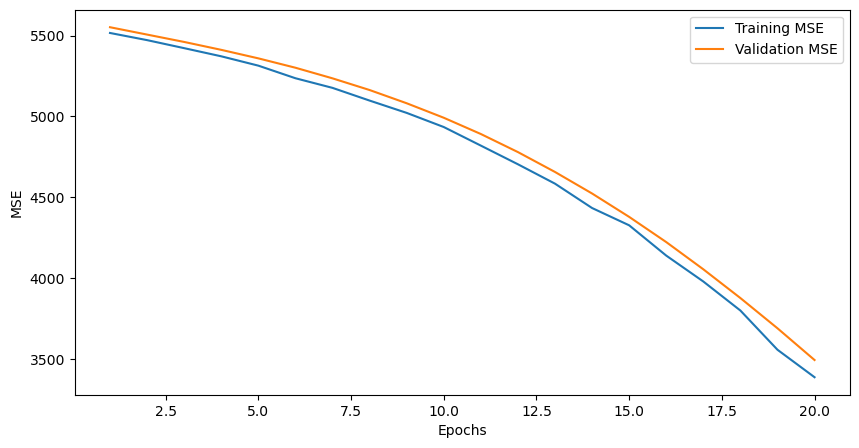

In [136]:
import matplotlib.pyplot as plt

train_mse = history.history['mse']
val_mse = history.history['val_mse']
epochs = range(1, len(train_mse)+1)

plt.figure(figsize=(10,5))
plt.plot(epochs, train_mse, label='Training MSE')
plt.plot(epochs, val_mse, label='Validation MSE')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.legend()
plt.show()